In [42]:
using Diffusions, Random, StatsBase, Flux, OneHotArrays, Distributions, Plots, Random, StatsPlots, LaTeXStrings

In [43]:
include("diffusion.jl")
include("loss.jl")
include("Diffusions.jl/src/maskedarrays.jl")

mask (generic function with 2 methods)

In [44]:
include("test.jl")

xt = [5, 2, 5, 4, 5, 2, 3, 5]
x0 = [1, 2, 3, 4, 1, 2, 3, 4]
_endpoint_conditioned_sample(rng, P, 0.4, 0.6, x0, xt) = [5, 2, 5, 4, 5, 2, 3, 4]


8-element Vector{Int64}:
 5
 2
 5
 4
 5
 2
 3
 4

In [45]:
import Diffusions: sampleforward

function sampleforward(rng::AbstractRNG, process::Process, t::Real, x::AbstractArray)
    x = copy(x)
    maskedvec(x) .= _sampleforward(rng, process, t, maskedvec(x))
    return x
end

function sampleforward(rng::AbstractRNG, process::Process, t::AbstractVector{<:Real}, x::AbstractArray)
    x = copy(x)
    for i in axes(x, ndims(x))
        maskedvec(x, i) .= _sampleforward(rng, process, t[i], maskedvec(x, i))
    end
    return x
end


sampleforward (generic function with 6 methods)

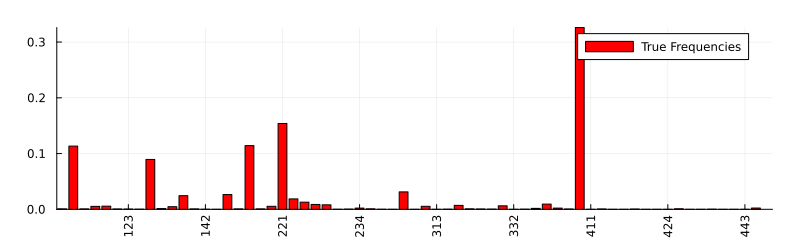

In [47]:
#Setting up a toy Markov sequence generator
S = [0.06591801058555521, 0.07969206822877058, 0.7577065839917972, 0.09668333719387696]
M1 = [0.08846562872099392 0.16990851783433247 0.7057593661240716 0.035866487320601916; 0.7431475939699389 0.21587009667771628 0.03183492266912633 0.009147386683218569; 0.5299436666548881 0.14037279287634963 0.31880667650890665 0.010876863959855763; 0.06768187476034546 0.8712803961334261 0.026959057317955764 0.03407867178827272]
M2 = [0.03711853694508748 0.004654670142378095 0.02356516471832978 0.9346616281942046; 0.05468190341435613 0.035849693778767566 0.010983526474084716 0.8984848763327916; 0.34718976966999127 0.29844003126407787 0.29174999882526814 0.06262020024066273; 0.06343354243884528 0.46980429610053 0.23584821143715762 0.23091395002346707]


#=
#If you wanted to draw the seq gen randomly
S = exp.(randn(4) .* 1.5)
S ./= sum(S)

M1 = exp.(randn(4,4) .* 1.5)
M1 ./= sum(M1 , dims = 2)

M2 = exp.(randn(4,4) .* 1.5)
M2 ./= sum(M2 , dims = 2)
=#


function target_sample(;S = S, M1 = M1, M2 = M2)
    a = rand(Categorical(S))
    b = rand(Categorical(M1[a,:]))
    c = rand(Categorical(M2[b,:]))
    return [a,b,c]
end

seq_matrix = hcat([[k,j,i] for i in 1:4, j in 1:4, k in 1:4]...)
all_seqs = [seq_matrix[:,i] for i in 1:size(seq_matrix,2)];
prob_seq(seq,S,M1,M2) = S[seq[1]]*M1[seq[1],seq[2]]*M2[seq[2],seq[3]]
all_probs = prob_seq.(all_seqs,Ref(S),Ref(M1),Ref(M2));

bar([join(string.(a)) for a in all_seqs], all_probs,
    xrotation = 90, size = (800,250), label = "True Frequencies",
    color = "red", margins = 0.5Plots.cm, xlim = (0,65))

In [48]:
#Setting up the model
alph = 5 #number of characters
hidden_size = 64

#We encode T with a non-trainable random projection
rff = RandomFourierFeatures(hidden_size, 1.0f0)

#A simple model that takes the full noised sequence and T,
#and returns the logits for each variable in the sequence
embed = Chain(Dense(15,hidden_size,leakyrelu),Dense(hidden_size,hidden_size,leakyrelu))
decode = Chain(
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size÷2),LayerNorm(hidden_size÷2),leakyrelu,
    Dense(hidden_size÷2, 15)
)
model(x,T) = reshape(
    decode(
        embed(
            reshape(x,(15,size(x)[end]))
             ) .+ rff(log(T))
           ),
    (5,3,size(x)[end]));

In [75]:
#Setting up the timestep schedule
timesteps = timeschedule(exp, Float32(0.001),Float32(1.0),100)

#Define the discrete diffusion process
# P = UniformDiscreteDiffusion(1.0,alph)
P = MaskedDiffusionLanguageModel(alph, 5, cosineschedule)

batch_size = 8
ps = Flux.params(embed, decode)
opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.0001))#Adam(0.001))
cumu_loss = 0.0
training_losses = Float64[];

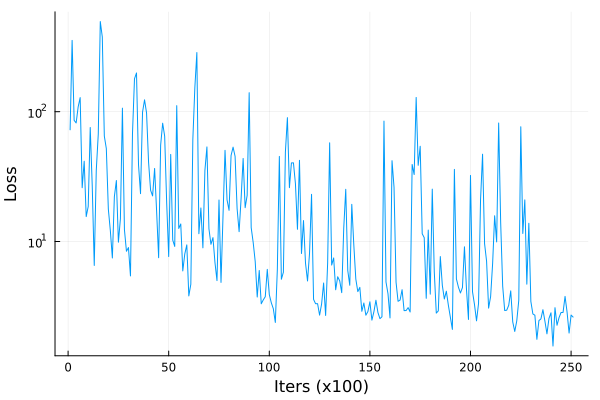

In [ ]:
for iter in 1:500000
    #Generate one batch of training data
    x = hcat([target_sample() for i in 1:batch_size]...)
    datOH = onehotbatch(x, 1:alph)

    #Sample T, then diffuse
    T = rand(timesteps) 
    
    diffused = sampleforward(P, T, x)
    diffusedOH = onehotbatch(diffused, 1:alph)

    #For scaling the loss
    scal = sqrt(1 - exp(-T))

    # @show model(diffusedOH, T)
    
    #Loss and gradient
    l,gs = Flux.withgradient(ps) do
        # The cross entropy loss is important for recovering the data distribution
        # Flux.logitcrossentropy(model(diffusedOH,T), datOH)/scal
        -standardloss(P, T, model(diffusedOH,T), datOH)[1]
    end
    
    #Update the parameters
    Flux.Optimise.update!(opt, ps, gs)
    
    cumu_loss += l
    if mod(iter,100) == 0
        opt[2].eta = opt[2].eta * 0.998 #Cheeky decay
        push!(training_losses, cumu_loss/100)
        cumu_loss = 0.0
        #Plotting loss
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none, ) |> IJulia.display
        sleep(0.01)
    end
end

IJulia.clear_output(true)
pl = plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none)

savefig(pl,"discrete_loss.pdf")
pl

In [51]:
import Diffusions: eq_dist
eq_dist(model::MaskedDiffusionLanguageModel) = Categorical(model.vocab_size)

eq_dist (generic function with 5 methods)

In [52]:
N = 20000
x_T = hcat([[5 for i in 1:3] for i in 1:N]...)

3×20000 Matrix{Int64}:
 5  5  5  5  5  5  5  5  5  5  5  5  5  …  5  5  5  5  5  5  5  5  5  5  5  5
 5  5  5  5  5  5  5  5  5  5  5  5  5     5  5  5  5  5  5  5  5  5  5  5  5
 5  5  5  5  5  5  5  5  5  5  5  5  5     5  5  5  5  5  5  5  5  5  5  5  5

In [53]:
import Diffusions: samplebackward

function checktimesteps(timesteps)
    length(timesteps) ≥ 2 || throw(ArgumentError("timesteps must have at least two timesteps"))
    issorted(timesteps) || throw(ArgumentError("timesteps must be increasing"))
    all(>(0), timesteps) || throw(ArgumentError("all timesteps must be positive"))
end

struct NullTracker end

track!(::NullTracker, t, x, x0) = nothing


struct Tracker
    time::Vector
    data::Vector
    x0::Vector
end

Tracker() = Tracker([], [], [])

function track!(tracker::Tracker, t, x, x0)
    push!(tracker.time, t)
    push!(tracker.data, x)
    push!(tracker.x0, x0)
    return nothing
end


function samplebackward(rng::AbstractRNG, guess, process, timesteps, x; tracker=NullTracker())
    checktimesteps(timesteps)
    i = lastindex(timesteps)
    t = timesteps[i]
    while i > firstindex(timesteps)
        s = timesteps[i-1]
        x_0 = guess(x, t)
        x = endpoint_conditioned_sample(rng, process, s, t, x_0, x)
        @show x
        # track!(tracker, s, x, x_0)
        t = s
        i -= 1
    end
    return x
end

samplebackward (generic function with 2 methods)

In [54]:
using StatsBase

function sample_sequences(probabilities::Array{Float32, 3})
    vocab_size, seq_length, num_samples = size(probabilities)
    
    # Initialize the output array
    sampled_sequences = zeros(Int, seq_length, num_samples)
    
    # Sample for each position in each sequence
    for i in 1:num_samples
        for j in 1:seq_length
            # Extract probabilities for this position in this sequence
            probs = probabilities[:, j, i]
            
            # Sample from the categorical distribution
            sampled_sequences[j, i] = sample(1:vocab_size, Weights(probs))
        end
    end
    
    return sampled_sequences
end

sample_sequences (generic function with 1 method)

In [55]:
function _endpoint_conditioned_sample(
    rng::AbstractRNG, 
    process::MaskedDiffusionLanguageModel, 
    s::Real, 
    t::Real, 
    x0::AbstractMatrix{Int}, 
    xt::AbstractMatrix{Int}
)
    @assert 0 ≤ s < t ≤ 1 "Invalid time steps: require 0 ≤ s < t ≤ 1"
    @assert size(x0) == size(xt) "x0 and xt must have the same size"
    
    vocab_size = process.vocab_size
    sequence_length, num_samples = size(xt)
    xs = copy(xt)
    
    α_s = process.α(s)[1]
    α_t = process.α(t)[1]

    for sample in 1:num_samples
        for i in 1:sequence_length
            if xt[i, sample] == process.mask_token_id
                # For masked tokens, compute probabilities
                probs = zeros(Float32, vocab_size)
                
                # Probability of keeping the mask
                probs[process.mask_token_id] = 1 - α_s
                
                # Probability of sampling the predicted token
                predicted_token = x0[i, sample]
                if 1 <= predicted_token <= vocab_size
                    probs[predicted_token] = α_s - α_t
                end
                
                # Normalize probabilities
                probs ./= sum(probs)
                
                # Sample new token
                xs[i, sample] = rand(rng, Categorical(probs))
            end
            # For unmasked tokens, xs[i, sample] remains unchanged (equal to xt[i, sample])
        end
    end

    return xs
end

_endpoint_conditioned_sample (generic function with 3 methods)

In [56]:
rng = Random.default_rng()

# diffusedOH = onehotbatch(x_T, 1:alph);

# Array{Float32, 3} <: AbstractVector

# @show size(softmax(model(diffusedOH, timesteps[5])));

# @show size(x_T);

size(softmax(model(diffusedOH, timesteps[5]))) = (5, 3, 20000)
size(x_T) = (3, 20000)


In [57]:
# @show typeof(softmax(model(diffusedOH, timesteps[5])));
# @show typeof(x_T);

typeof(softmax(model(diffusedOH, timesteps[5]))) = Array{Float32, 3}
typeof(x_T) = Matrix{Int64}


In [58]:
# x_0 = sample_sequences(softmax(model(diffusedOH, timesteps[5])));

# @show x_0;
# @show x_T;

x_0 = [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 3 1 1 1 3 3 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 1 1 1 2 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 1 1 1 1 1 3 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 1 3 1 1 1 1 1 3 3 1 1 1 1 1 1 1 3 1 1 1 1 1 1 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 3 1 1 1 1 1 1 3 2 1 1 1 1 1 1 3 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 2 1 1 3 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 3 1 1 3 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 1 1 1

In [27]:
# @show _endpoint_conditioned_sample(rng, P, 0.5, 0.7, x_0, x_T)[:, 1];

(_endpoint_conditioned_sample(rng, P, 0.5, 0.7, x_0, x_T))[:, 1] = [5, 2, 5]


In [59]:
function endpoint_conditioned_sample(rng::AbstractRNG, process::Process, s::Real, t::Real, x_0::AbstractArray, x_t::AbstractArray)
    if x_t isa MaskedArray
        # x_0 inherits masked elements from x_t
        x_0 = MaskedArray(x_0, x_t.indices)
    end
    x = copy(x_t)
    maskedvec(x) .= _endpoint_conditioned_sample(rng, process, s, t, maskedvec(x_0), maskedvec(x_t))
    return x
end

endpoint_conditioned_sample(rng::AbstractRNG, process, s::Real, t::Real, x_0, x_t) =
    endpoint_conditioned_sample.(rng, process, s, t, x_0, x_t)

# sample x at time s conditioned on x_0 at time 0 and x_t at time t
endpoint_conditioned_sample(P::Process, s::Real, t::Real, x_0, x_t) = endpoint_conditioned_sample(Random.default_rng(), P, s, t, x_0, x_t)


endpoint_conditioned_sample (generic function with 3 methods)

In [29]:
# _endpoint_conditioned_sample(rng, P, timesteps[1], timesteps[100], sample_sequences(softmax(model(diffusedOH, timesteps[100]))), x_T)

3×20000 Matrix{Int64}:
 3  3  3  3  3  3  3  2  3  2  3  3  3  …  3  1  3  3  3  3  4  3  1  2  3  2
 1  3  3  1  1  4  2  1  1  1  3  3  1     1  2  1  2  3  1  2  1  1  1  2  1
 1  4  4  4  4  3  4  2  4  1  4  3  4     4  4  4  4  4  4  4  4  4  4  4  4

In [73]:
#First draw samples from the equilibrium distribution of the process
eq = eq_dist(P)
N = 20000
x_T = hcat([[5 for i in 1:3] for i in 1:N]...)
# x_T = hcat([[rand(eq_dist(P)) for i in 1:3] for i in 1:N]...)

#Instead of an expectation, discrete diffusion needs us to draw a sample from the marginal for each variable
function zero_sample(x_t, t)
    diffusedOH = onehotbatch(x_t, 1:alph)
     #return randcat(rng, softmax(model(diffusedOH,t)))
    return sample_sequences(softmax(model(diffusedOH, t)))
end

#Run the backward diffution
@time samp = samplebackward(zero_sample, P, timesteps, x_T);

#Collect these samples
diff_samples = [samp[:,i] for i in 1:size(samp,2)];

x = [5 5 5 3 5 5 5 5 5 5 5 5 3 5 5 5 5 5 5 5 5 5 5 2 5 5 5 5 5 5 5 5 1 5 5 5 5 5 5 5 5 5 5 2 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 2 5 5 5 5 5 5 5 5 1 5 5 5 5 5 5 5 5 5 5 5 5 2 5 5 5 5 5 5 5 5 5 2 5 5 3 5 5 5 5 5 5 5 5 5 5 5 5 1 5 5 5 1 5 5 5 5 5 5 5 5 5 5 5 1 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 1 5 1 5 5 5 5 5 5 5 5 5 5 3 5 2 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 1 5 5 3 5 5 5 5 5 5 3 1 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5 3 5 5 5 5 5 5 5 5 5 3 5 5 5 5 5 5 5 5 5 5 5 5 3 5 5 3 5 5 2 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5 5 5 2 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 1 5 5 5 3 5 5 5 2 5 5 5 5 5 1 5 5 5 3 5 5 5 5 5 5 3 5 5 5 5 5 5 2 5 5 1 5 5 5 5 5 2 5 5 5 2 5 5 3 5 5 5 5 5 5 5 5 2 5 5 5 5 5 5 2 5 5 5 5 5 3 1 5 5 5 5 5 5 5 3 5 5 5 5 2 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 3 5 5 5 5 5 5 5 5 5 5 5 2 5 5 3 5 5 5 1 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 2 5 3 2 5 5 2 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5

Excessive output truncated after 545572 bytes.

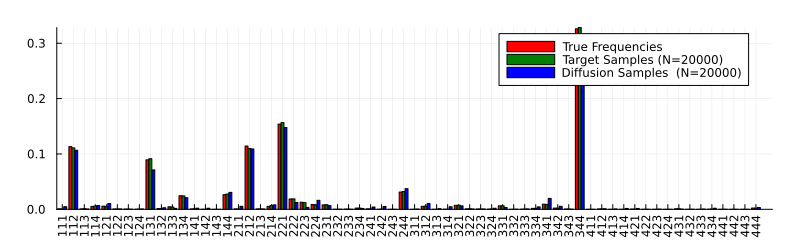

In [74]:
#Plotting
target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_flux64.pdf")
pl

In [35]:
#And how to do it with IJ, which takes one-hots
P = IndependentDiscreteDiffusion((alph-1)/alph,ones(alph)) #This should be equiv to UniformDiscreteDiffusion(1.0,alph)

LoadError: MethodError: no method matching IndependentDiscreteDiffusion(::Float64, ::Vector{Float64})

[0mClosest candidates are:
[0m  IndependentDiscreteDiffusion(::Real, [91m::StaticArraysCore.SVector{K, <:Real}[39m) where K
[0m[90m   @[39m [33mDiffusions[39m [90m~/.julia/dev/Diffusions/src/[39m[90m[4mdiscrete.jl:27[24m[39m


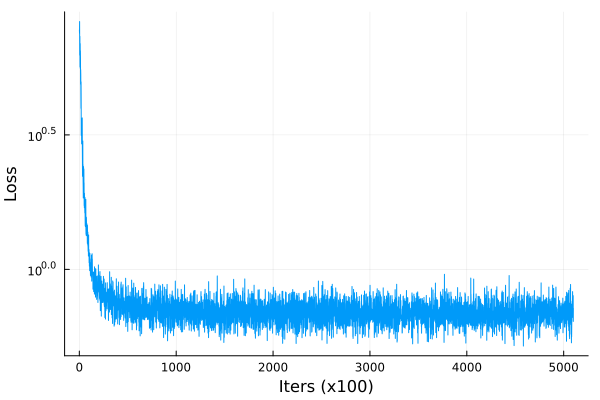

In [9]:
#Since this IndependentDiscreteDiffusion process is equivalent, the model from above should be "pre-trained"
#let's check if the loss resumes from where it left off
for iter in 1:10000
    x = hcat([target_sample() for i in 1:batch_size]...)
    datOH = onehotbatch(x, 1:alph)
    T = rand(timesteps)    
    diffusedOH = sampleforward(P, T, datOH) #Note, we diffuse the one-hots
    scal = sqrt(1 - exp(-T))
    l,gs = Flux.withgradient(ps) do
        Flux.logitcrossentropy(model(diffusedOH,T), datOH)/scal
    end
    Flux.Optimise.update!(opt, ps, gs)
    cumu_loss += l 
    if mod(iter,100) == 0
        opt[2].eta = opt[2].eta * 0.997
        push!(training_losses, cumu_loss/100)
        cumu_loss = 0.0
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none) |> IJulia.display
        sleep(0.01)
    end
end
IJulia.clear_output(true)
plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none)

In [10]:
function zero_sample(x_t, t)
    #randcat here maintains onehot
    sm = softmax(model(x_t,t))
    return onehotbatch(randcat(sm),1:size(sm,1))
end

eq = Categorical(ones(alph)./alph);
N = 10000
#We init with onehots
x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:N]...), 1:alph);

@time samp = onecold(samplebackward(zero_sample, P, timesteps, x_T),1:alph);
diff_samples = [samp[:,i] for i in 1:size(samp,2)];

  6.777294 seconds (6.46 M allocations: 7.666 GiB, 34.53% gc time, 17.60% compilation time)


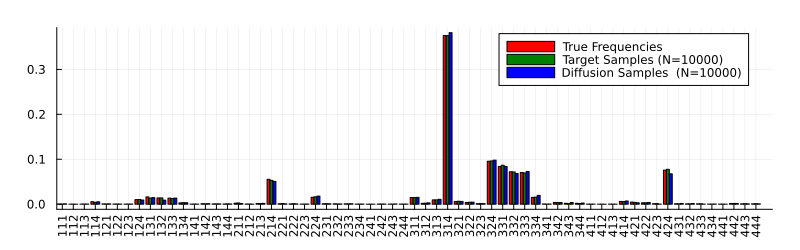

In [11]:
target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_fluxIJ.pdf")
pl

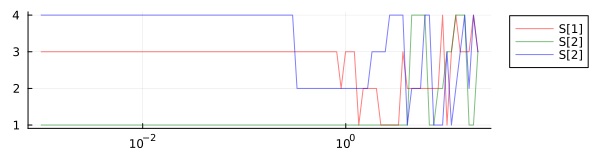

In [12]:
#A trajectory with an NN-trained model
x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:1]...), 1:alph);
track = Diffusions.Tracker()
samp = onecold(samplebackward(zero_sample, P, timesteps, x_T, tracker = track),1:alph);

#An example of a single discrete trajectory
plot(track.time,hcat([v[:] for v in onecold.(track.data,(1:alph,))]...)', xscale = :log10, alpha = 0.5, size = (600,150), 
    legend=:outertopright, color = ["red" "green" "blue"], label = ["S[1]" "S[2]" "S[2]"])

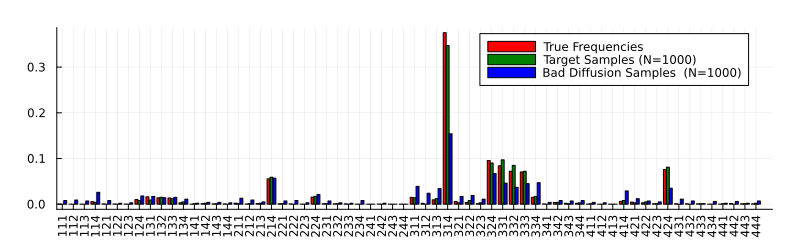

In [13]:
#Using the expected freqs, without sampling, does NOT work for the discrete case!
function expect(x_t, t)
    return softmax(model(x_t,t)) #Just the exepected freqs
end

N = 1000
x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:N]...), 1:alph);

samp = onecold(samplebackward(expect, P, timesteps, x_T),1:alph);
diff_samples = [samp[:,i] for i in 1:size(samp,2)];

target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Bad Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_flux_nosample.pdf")
pl

In [14]:
#Closed-form (ie. no trained NN) to investigate behavior/convergence etc.

#"product of marginals" for each variable in the sequence
#This is what you get from the backward pass, because each variable is diffused independently
#For the closed form calculation, this is P(xt|x0), where "seq" is x0, considered as a function of x0.
independent_seq_prob(seq,state) = state[seq[1],1]*state[seq[2],2]*state[seq[3],3]

#The above gets multiplied by P(x0) (ie. all_probs, the target distribution) to get P(x0|xt) ∝ P(x0)P(xt|x0)
#The marginals for each variable in x0 are then sampled from, independently.
function direct_zero_sample(x_t, T; P = P, all_seqs = all_seqs, all_probs = all_probs)
    backw = Diffusions.backward(P,x_t,0.0,T)
    for i in 1:size(x_t,3)
        bck = backw[:,:,i]
        p = all_probs .* independent_seq_prob.(all_seqs,(bck,))
        p = p ./ sum(p)

        #Calculating the "per site" probabilities implied by the joint p
        bck .= 0.0
        for (i,s) in enumerate(all_seqs)
            bck[s[1],1] += p[i]
            bck[s[2],2] += p[i]
            bck[s[3],3] += p[i]
        end
        bck .= bck ./ sum(bck, dims = 1) 
        backw[:,:,i] .= onehotbatch(randcat(bck),1:size(bck,1)) #flag
    end
    return backw
end

direct_zero_sample (generic function with 1 method)

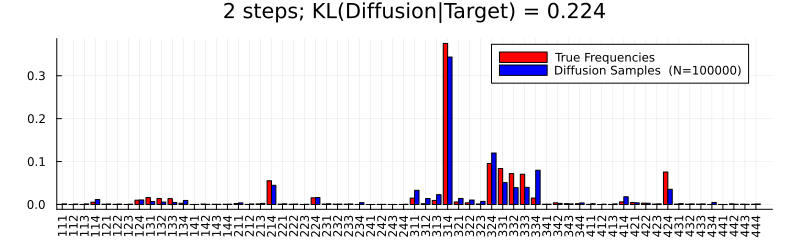

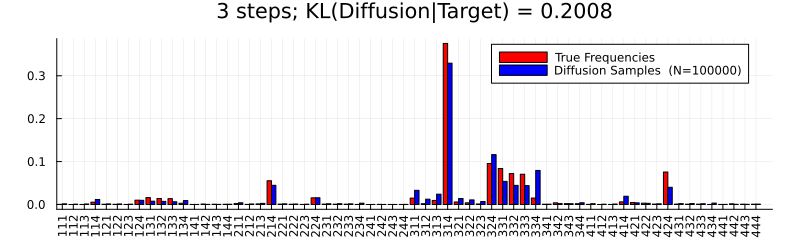

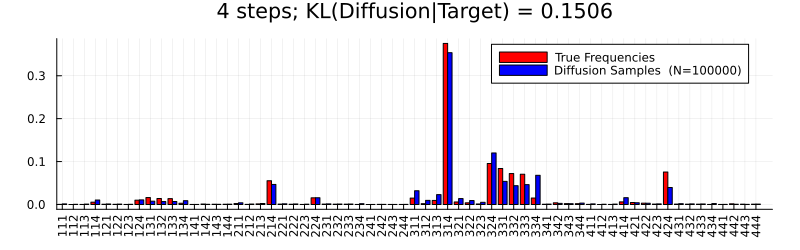

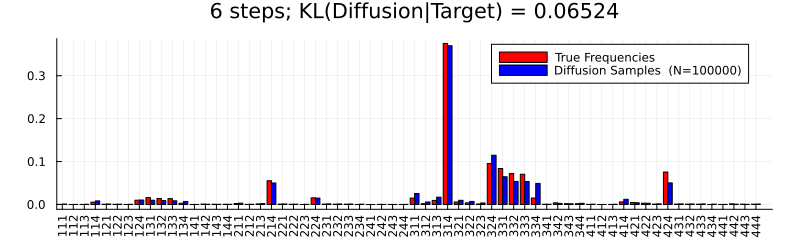

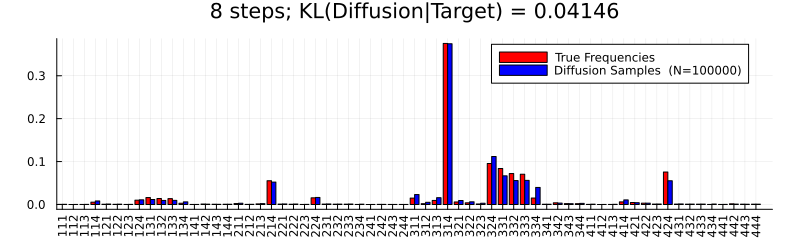

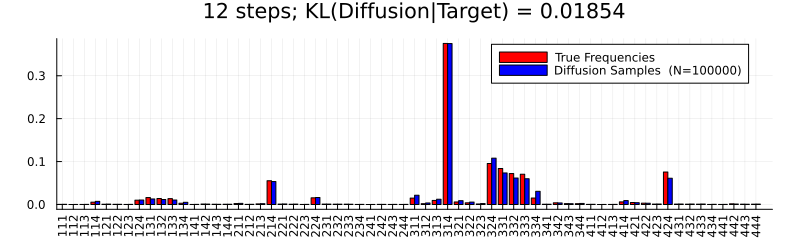

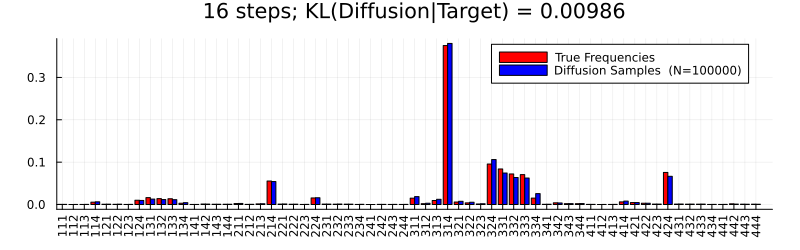

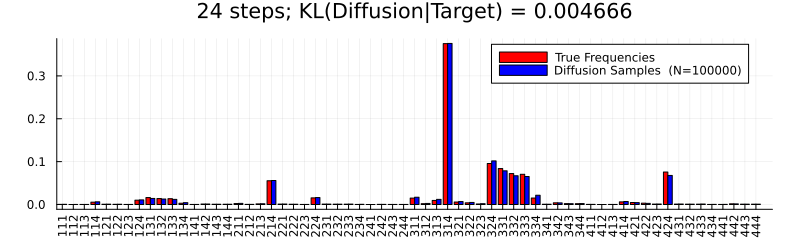

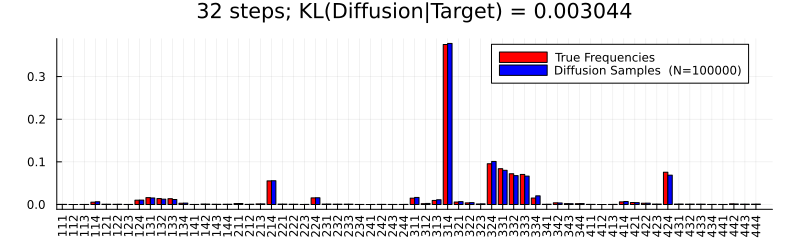

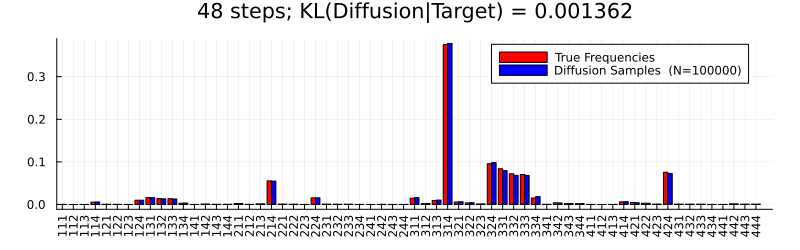

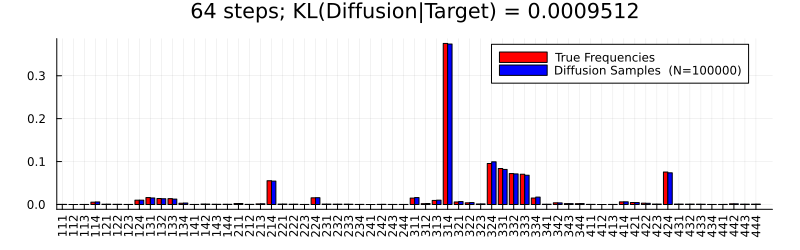

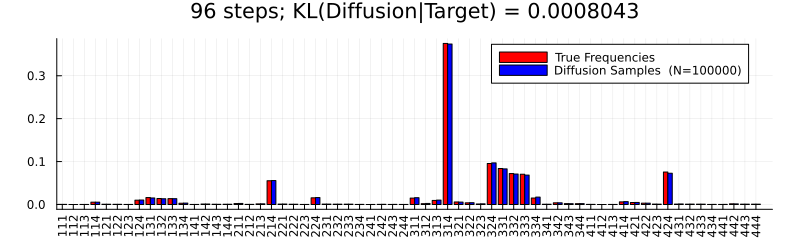

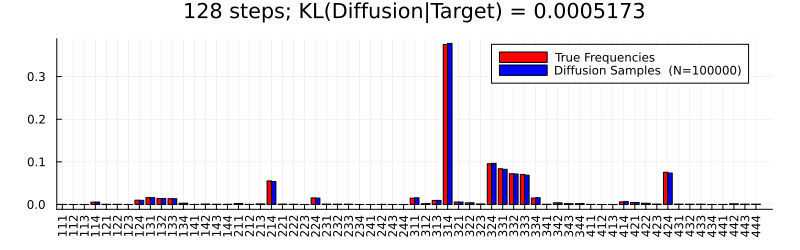

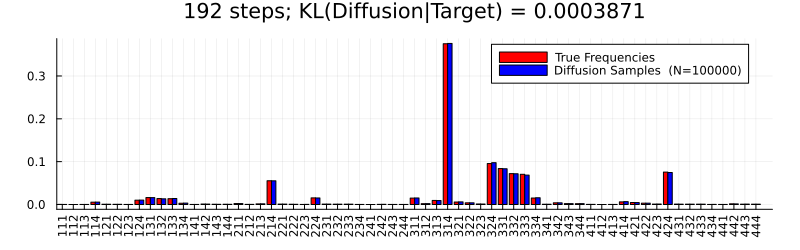

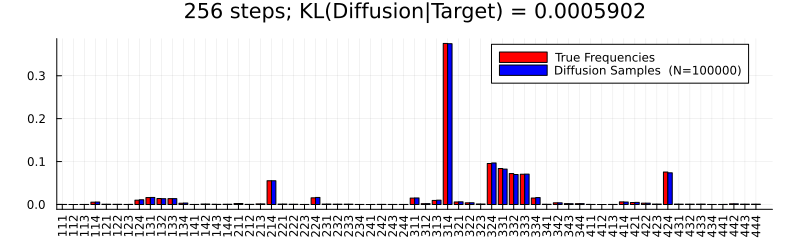

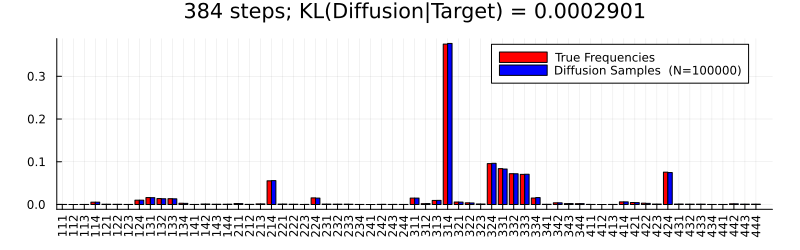

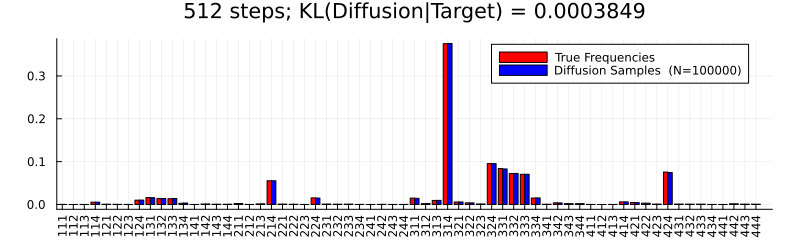

In [15]:
#Investigating the convergence on the true joint distribution using the direct expectation calculation
KLterm(p,q) = p > 0 ? p*log(p/q) : 0.0
KLdiv(Pdict,Qdict) = sum([KLterm(get(Pdict,k,0.0),get(Qdict,k,0.0)) for k in union(keys(Pdict),keys(Qdict))])

KLDs = Float64[]

steplist = [2,3,4,6,8,12,16,24,32,48,64,96,128,192,256,384,512]
for steps in steplist
    timesteps = timeschedule(exp, Float32(0.001),Float32(20.0),steps+1)

    eq = Categorical(ones(alph)./alph);
    N = 100000
    x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:N]...), 1:alph);

    samp = onecold(samplebackward(direct_zero_sample, P, timesteps, x_T),1:alph);
    diff_samples = [samp[:,i] for i in 1:size(samp,2)];
    prop_d = proportionmap(diff_samples)
    

    diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
    
    kld = round(KLdiv(prop_d,Dict(zip(all_seqs,all_probs))), sigdigits = 4)
    push!(KLDs,kld)
    
    pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs diff_freqs],
        xrotation = 90, size = (800,250), label = ["True Frequencies" "Diffusion Samples  (N=$(N))"],
        color = ["red" "blue"], margins = 0.5Plots.cm, xlim = (0,65), title = "$(steps) steps; KL(Diffusion|Target) = $(kld)")
    display(pl)
    if steps in [2,16,64,256]
        savefig(pl,"discrete_diff_direct_$(steps)_steps.pdf")
    end
end

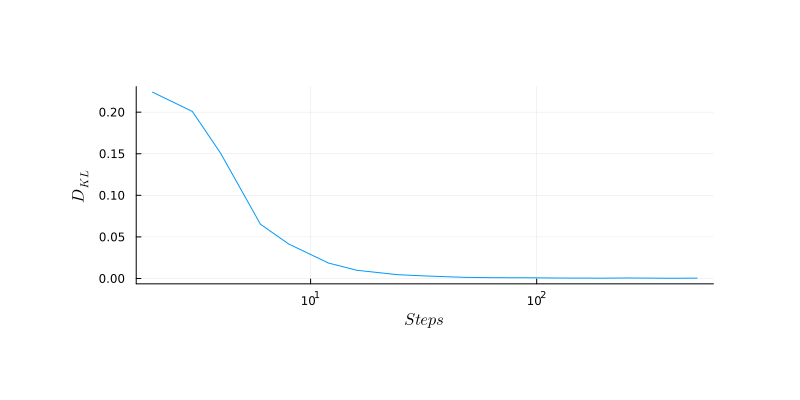

In [16]:
#KL divergence of samples vs true distribution as sampling steps increases
pl = plot(steplist, KLDs, xscale = :log10, size = (800,400),
    ylabel = L"D_{KL}", margins = 2Plots.cm, label = :none, xlabel = L"Steps")
savefig(pl,"discrete_KL_vs_steps_logschedule.pdf")
pl

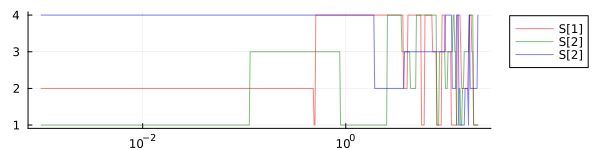

In [17]:
#A trajectory with an directly calculated zero sample
x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:1]...), 1:alph);
track = Diffusions.Tracker()
samp = onecold(samplebackward(direct_zero_sample, P, timesteps, x_T, tracker = track),1:alph);

#An example of a single discrete trajectory
plot(track.time,hcat([v[:] for v in onecold.(track.data,(1:alph,))]...)', xscale = :log10, alpha = 0.5, size = (600,150), 
    legend=:outertopright, color = ["red" "green" "blue"], label = ["S[1]" "S[2]" "S[2]"])